# Provera na novim fotografijama

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import joblib
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, str(Path.cwd()))
from data_utils import LABEL_TO_LETTER, LETTER_TO_LABEL, IMG_SIZE, NUM_CLASSES, EXCLUDED_LABELS

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## Konstante i putanje

In [2]:
CUSTOM_PHOTOS_DIR = Path("../data/custom_photos")

CNN_MODEL_PATH = Path("../results/CNN model/cnn_model.pt")
EMBEDDING_MODEL_PATH = Path("../results/Triplet model/embedding_net.pt")
KNN_MODEL_PATH = Path("../results/KNN model/knn_classifier.pkl")

RESULTS_DIR = Path("../results/Nove fotografije")
RESULTS_DIR.mkdir(exist_ok=True)

EMBEDDING_DIM = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Uređaj: {DEVICE}")

SORTED_LABELS = sorted(LABEL_TO_LETTER.keys())
LABEL_TO_IDX = {label: idx for idx, label in enumerate(SORTED_LABELS)}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

Uređaj: cpu


## Arhitektura već obučenih modela - prekopirano iz 03. i 04. notebook-ova

In [3]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
        )

        # 28 -> 14 -> 7 -> 3 (posle tri MaxPool2d(2), floor deljenje)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=EMBEDDING_DIM):
        super().__init__()

        # Ista arhitektura kao ya CNN
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
        )

        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, embedding_dim),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.embedding(x)
        x = F.normalize(x, p=2, dim=1)  # L2 normalizacija - svaki embedding vektor ima jediničnu dužinu
        return x

## Učitavanje već obučenih modela

In [4]:
cnn_model = BaselineCNN().to(DEVICE)
cnn_model.load_state_dict(torch.load(CNN_MODEL_PATH, map_location=DEVICE))
cnn_model.eval()

embedding_model = EmbeddingNet().to(DEVICE)
embedding_model.load_state_dict(torch.load(EMBEDDING_MODEL_PATH, map_location=DEVICE))
embedding_model.eval()

knn_model = joblib.load(KNN_MODEL_PATH)

print("Bazni CNN, Embedding mreža i KNN klasifikator uspešno učitani (bez ponovnog treniranja).")

Bazni CNN, Embedding mreža i KNN klasifikator uspešno učitani (bez ponovnog treniranja).


C:\Users\Ana\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Učitavanje i priprema fotografija

In [5]:
def load_and_prepare_photo(path):
    """Učitava fotografiju sa diska i priprema je u isti format koji modeli očekuju
    (sivi tonovi, kvadratni kadar, 28x28, pikseli u [0, 1])."""
    img = Image.open(path).convert("L")  # sivi tonovi

    # centralno isecanje u kvadrat, da se slika ne izobliči pri smanjenju rezolucije
    w, h = img.size
    side = min(w, h)
    left = (w - side) // 2
    top = (h - side) // 2
    img = img.crop((left, top, left + side, top + side))

    img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

    pixels = np.asarray(img, dtype=np.float32) / 255.0
    return pixels


def true_label_from_filename(path):
    """Očekivani format naziva: <SLOVO>_<bilo šta>.jpg, npr. A_1.jpg"""
    letter = path.stem.split("_")[0].upper()
    if letter not in LETTER_TO_LABEL:
        raise ValueError(
            f"Ne mogu da prepoznam slovo iz naziva fajla '{path.name}' "
            f"(očekivan format SLOVO_broj.jpg, npr. A_1.jpg; J i Z nisu podržani)."
        )
    return LETTER_TO_LABEL[letter]


photo_paths = sorted(
    p for p in CUSTOM_PHOTOS_DIR.glob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

if not photo_paths:
    print(
        f"Nema fotografija u '{CUSTOM_PHOTOS_DIR}'.\n"
        "Dodati fotografije (format SLOVO_broj.jpg, npr. A_1.jpg) i ponovo pokrenuti notebook."
    )
else:
    print(f"Pronađeno {len(photo_paths)} fotografija: {[p.name for p in photo_paths]}")

Pronađeno 12 fotografija: ['C_1.jpeg', 'E_1.jpeg', 'E_2.jpeg', 'H_1.jpg', 'L_1.jpeg', 'N_1.jpg', 'O_1.JPG', 'R_1.jpg', 'U_1.jpeg', 'V_1.jpeg', 'W_1.jpeg', 'Y_1.jpeg']


## Predikcije oba modela

In [6]:
def predict_cnn(pixels):
    x = torch.from_numpy(pixels).unsqueeze(0).unsqueeze(0).to(DEVICE)  # (1, 1, 28, 28)
    with torch.no_grad():
        logits = cnn_model(x)
        idx_pred = int(logits.argmax(dim=1).item())
    return IDX_TO_LABEL[idx_pred]  # nazad u originalnu labelu


def predict_triplet_knn(pixels):
    x = torch.from_numpy(pixels).unsqueeze(0).unsqueeze(0).to(DEVICE)  # (1, 1, 28, 28)
    with torch.no_grad():
        embedding = embedding_model(x).cpu().numpy()
    return int(knn_model.predict(embedding)[0])


results = []
for path in photo_paths:
    pixels = load_and_prepare_photo(path)
    true_label = true_label_from_filename(path)

    cnn_pred_label = predict_cnn(pixels)
    knn_pred_label = predict_triplet_knn(pixels)

    results.append({
        "fajl": path.name,
        "pixels": pixels,
        "stvarno_slovo": LABEL_TO_LETTER[true_label],
        "cnn_predikcija": LABEL_TO_LETTER[cnn_pred_label],
        "triplet_knn_predikcija": LABEL_TO_LETTER[knn_pred_label],
        "cnn_tacno": cnn_pred_label == true_label,
        "triplet_knn_tacno": knn_pred_label == true_label,
    })

for r in results:
    print(
        f"{r['fajl']:<14} stvarno={r['stvarno_slovo']}  "
        f"CNN={r['cnn_predikcija']} ({'OK' if r['cnn_tacno'] else 'greška'})  "
        f"Triplet+KNN={r['triplet_knn_predikcija']} ({'OK' if r['triplet_knn_tacno'] else 'greška'})"
    )

C_1.jpeg       stvarno=C  CNN=C (OK)  Triplet+KNN=C (OK)
E_1.jpeg       stvarno=E  CNN=N (greška)  Triplet+KNN=M (greška)
E_2.jpeg       stvarno=E  CNN=P (greška)  Triplet+KNN=E (OK)
H_1.jpg        stvarno=H  CNN=P (greška)  Triplet+KNN=P (greška)
L_1.jpeg       stvarno=L  CNN=T (greška)  Triplet+KNN=L (OK)
N_1.jpg        stvarno=N  CNN=N (OK)  Triplet+KNN=N (OK)
O_1.JPG        stvarno=O  CNN=O (OK)  Triplet+KNN=O (OK)
R_1.jpg        stvarno=R  CNN=R (OK)  Triplet+KNN=K (greška)
U_1.jpeg       stvarno=U  CNN=K (greška)  Triplet+KNN=U (OK)
V_1.jpeg       stvarno=V  CNN=K (greška)  Triplet+KNN=U (greška)
W_1.jpeg       stvarno=W  CNN=W (OK)  Triplet+KNN=B (greška)
Y_1.jpeg       stvarno=Y  CNN=Y (OK)  Triplet+KNN=Y (OK)


## Vizuelni prikaz rezultata

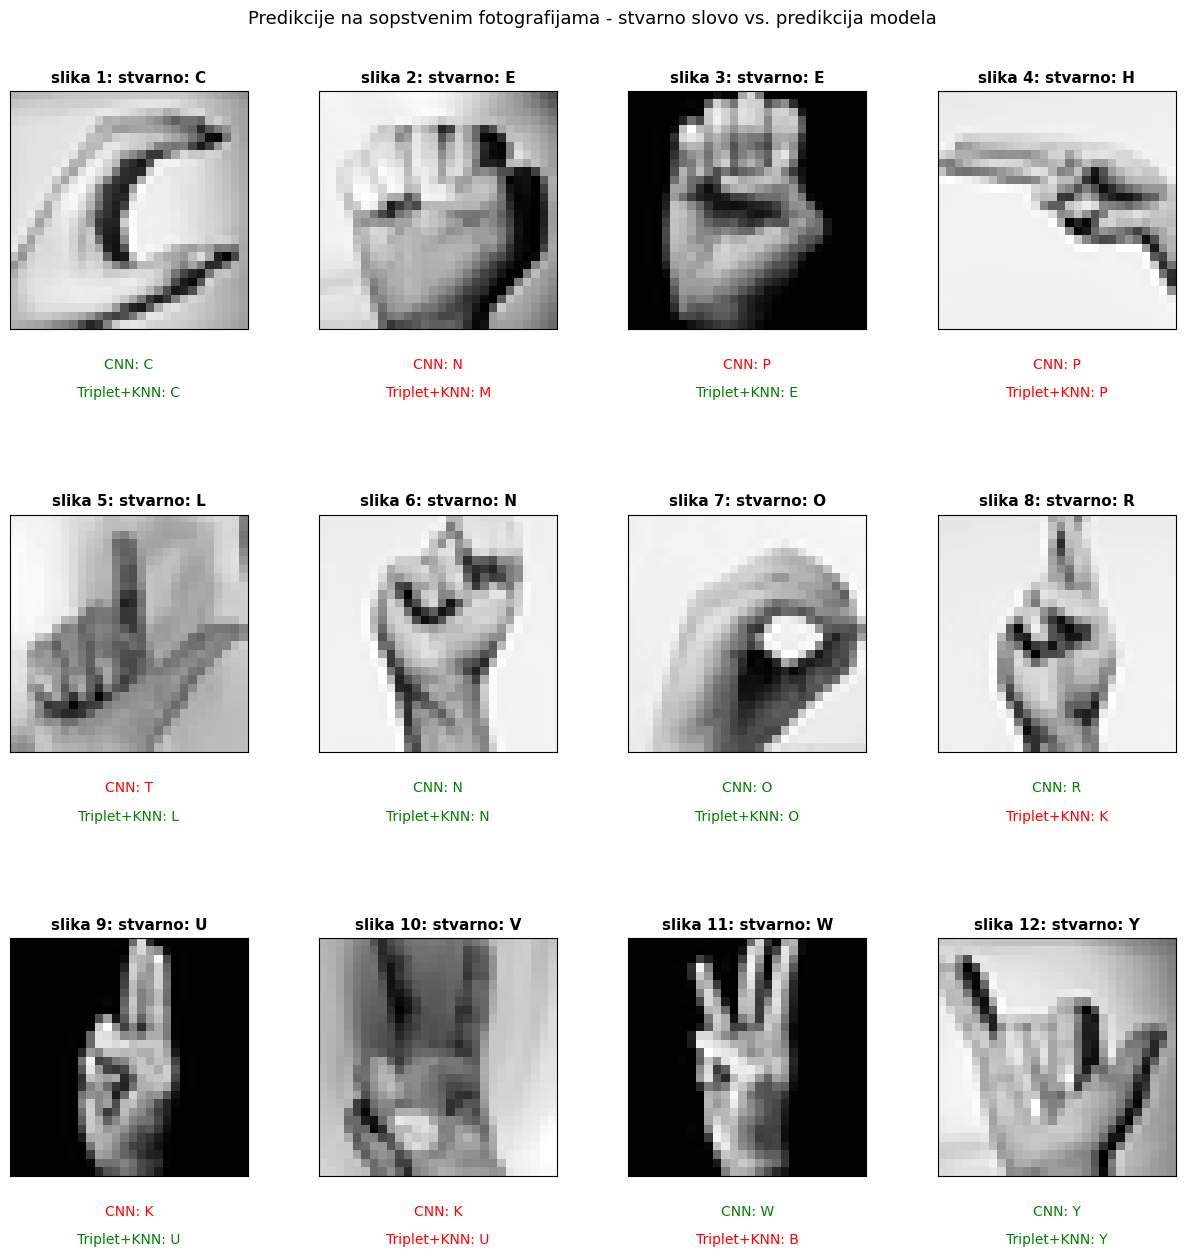

In [7]:
n = len(results)
i = 0
if n > 0:
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(
        rows, cols, figsize=(3.1 * cols, 4.2 * rows),
        gridspec_kw={"hspace": 0.7, "wspace": 0.3},
    )
    axes = np.atleast_1d(axes).flatten()

    for ax, r in zip(axes, results):
        i += 1
        ax.imshow(r["pixels"], cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"slika {i}: stvarno: {r['stvarno_slovo']}", fontsize=11, fontweight="bold")

        cnn_color = "green" if r["cnn_tacno"] else "red"
        knn_color = "green" if r["triplet_knn_tacno"] else "red"
        ax.text(
            0.5, -0.12, f"CNN: {r['cnn_predikcija']}",
            transform=ax.transAxes, ha="center", va="top", color=cnn_color, fontsize=10,
        )
        ax.text(
            0.5, -0.24, f"Triplet+KNN: {r['triplet_knn_predikcija']}",
            transform=ax.transAxes, ha="center", va="top", color=knn_color, fontsize=10,
        )

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle("Predikcije na sopstvenim fotografijama - stvarno slovo vs. predikcija modela", fontsize=13)
    fig.subplots_adjust(top=0.92, bottom=0.05, left=0.03, right=0.97)
    plt.savefig(RESULTS_DIR / "nove_fotografije_predikcije.png", dpi=150, bbox_inches="tight")
    plt.show()

1. slika (naša fotografija): stvarna klasa **C**, predviđena klasa **C** od oba modela
2. slika (naša fotografija): stvarna klasa **E**, predviđena klasa od prvog modela **N**, od drugog **M** - tačna pretpostavka iz EDA-e da model može tu da greši
3. slika (preuzeta sa interneta): stvarna klasa **E**, drugi model je dobro predvideo **E**
4.   slika (preuzeta sa interneta): predviđa **P**, a piše da je stvarna klasa **H**. Slika je preuzeta sa interneta i možemo primetiti da je ovde *slovo H predstavljeno pogrešno*, tj. suprotno pozicionirano, tako da je ovo kao *outlier*. Labela mu je H, a ustvari je ovo kao da smo na pravo H primenili horizontalni flip, tj. okrenuli u ogledalu i na taj način je slovo dobilo pogrešno značenje, u ovom slučaju nepostojeće. A ako pogledamo ovaj znak zapravo je najpribližniji po našoj slobodnoj proceni slovu P, tako da **ne bismo rekle da je model ovde pogrešio.**
5.   slika (naša fotografija): stvarno slovo **L**, model sa embedinzima je tačno predvideo
6.    slika (preuzeta sa interneta): stvarno slovo **N** i oba modela su dobro predvidela
7. slika (preuzeta sa interneta): stvarno slovo **O** i oba modela su dobro predvidela
8.  slika (preuzeta sa interneta): stvarno slovo **R**, a u ovom slučaju bolje predviđanje je postigao 1. model
9.  slika (preuzeta sa interneta): stvarno slovo **U**, a 2. model je dobro predvideo
10.  slika (naša fotografija): stvarno slovo **V**, oba modela greše, mi smo pretpostavile da će ovo slovo verovatno biti problem, a možda smo i loše pozicionirale prste na fotografiji
11.   slika (preuzeta sa interneta): stvarno slovo **W**, 1. model je dobro predvideo
12.    slika (naša fotografija): stvarno slovo je **Y**, a predviđeno je **Y** od strane oba modela